In [1]:
!pip install -q sentence-transformers

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [26]:
model = SentenceTransformer("BAAI/bge-small-en-v1.5")
print("Embedding Dimension: ", model.get_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Dimension:  384


In [27]:
sentences = [
    "The cat sat on the mat.",
    "A feline was resting on the rug.",       # paraphrase of sentence 0
    "The stock market crashed today.",         # unrelated
    "Financial markets saw a massive decline.", # paraphrase of sentence 2
    "The dog did not bite the man.",
    "The man did not bite the dog."
]

embeddings = model.encode(sentences)
print("Shape:", embeddings.shape)   # (4, 384)
print("First 10 values of embedding 0:\n", embeddings[0][:10])

Shape: (6, 384)
First 10 values of embedding 0:
 [ 0.03134573 -0.01093656  0.00309489  0.06605193 -0.03665362 -0.00497782
  0.08562852  0.09260138  0.06794264  0.04467067]


In [28]:
sim_matrix = cosine_similarity(embeddings)

import pandas as pd
df = pd.DataFrame(sim_matrix,
                   index=[f"S{i}" for i in range(len(sentences))],
                   columns=[f"S{i}" for i in range(len(sentences))])
print(df.round(3))

# Expect: S0-S1 high similarity (paraphrase), S2-S3 high similarity,
# but S0/S1 vs S2/S3 low similarity

       S0     S1     S2     S3     S4     S5
S0  1.000  0.762  0.436  0.340  0.476  0.460
S1  0.762  1.000  0.412  0.337  0.553  0.520
S2  0.436  0.412  1.000  0.777  0.402  0.390
S3  0.340  0.337  0.777  1.000  0.314  0.309
S4  0.476  0.553  0.402  0.314  1.000  0.986
S5  0.460  0.520  0.390  0.309  0.986  1.000


In [36]:
# ============================================
# CELL 4: Mini semantic search engine (the actual RAG retrieval step)
# ============================================
documents = [
    "Python is a popular programming language for data science.",
    "The Eiffel Tower is located in Paris, France.",
    "Machine learning models require large amounts of training data.",
    "Paris is the capital city of France.",
    "Deep learning is a subset of machine learning using neural networks.",
    "The dog did not bite the man.",
    "The man did not bite the dog."
]

doc_embeddings = model.encode(documents)
print("Doc embedding dimensions: ", doc_embeddings.shape)

def semantic_search(query, top_k=3):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]
    ranked_idx = np.argsort(scores)[::-1][:top_k]
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.4f} | {documents[idx]}")

print("Query: 'Where is the Eiffel Tower?'\n")
semantic_search("Where is the Eiffel Tower?")

print("\nQuery: 'Tell me about neural networks'\n")
semantic_search("Tell me about neural networks")

print("\nQuery: 'What happened to man'\n")
semantic_search("what happened to man?")

Doc embedding dimensions:  (7, 384)
Query: 'Where is the Eiffel Tower?'

Score: 0.9040 | The Eiffel Tower is located in Paris, France.
Score: 0.7049 | Paris is the capital city of France.
Score: 0.3542 | Python is a popular programming language for data science.

Query: 'Tell me about neural networks'

Score: 0.8069 | Deep learning is a subset of machine learning using neural networks.
Score: 0.6975 | Machine learning models require large amounts of training data.
Score: 0.6289 | Python is a popular programming language for data science.

Query: 'What happened to man'

Score: 0.5385 | The man did not bite the dog.
Score: 0.5345 | The dog did not bite the man.
Score: 0.4316 | Python is a popular programming language for data science.


### Testing with Adversarial Documents

I will now add two adversarial documents and observe how the semantic search performs. Adversarial documents are designed to have keywords that might overlap with other topics but have a different core meaning, potentially confusing the model if it relies too heavily on superficial keyword matching rather than true semantic understanding.

In [39]:
adversarial_documents = [
    "The financial institution, Bank of America, announced its quarterly earnings.", # Financial bank
    "After the flood, the river bank was completely eroded, threatening nearby homes."
]

# Extend the existing documents list with adversarial ones
# Note: This assumes `documents` is accessible from the previous cell's execution context.
# If the kernel is restarted, `documents` would need to be re-defined or re-loaded.
original_documents_count = len(documents)
documents.extend(adversarial_documents)

print(f"Added {len(adversarial_documents)} new documents. Total documents: {len(documents)}")

# Re-encode all documents, including the new adversarial ones
doc_embeddings = model.encode(documents)
print("New Doc embedding dimensions: ", doc_embeddings.shape)

print("\nQuery: 'financial services of a bank'\n")
semantic_search("financial services of a bank")

print("\nQuery: 'river erosion and banks'\n")
semantic_search("river erosion and banks")

print("\nQuery: 'What is a bank?'\n")
semantic_search("What is a bank?")

Added 2 new documents. Total documents: 9
New Doc embedding dimensions:  (9, 384)

Query: 'financial services of a bank'

Score: 0.6538 | The financial institution, Bank of America, announced its quarterly earnings.
Score: 0.5446 | Python is a popular programming language for data science.
Score: 0.5269 | Machine learning models require large amounts of training data.

Query: 'river erosion and banks'

Score: 0.6986 | After the flood, the river bank was completely eroded, threatening nearby homes.
Score: 0.5135 | Python is a popular programming language for data science.
Score: 0.5119 | Machine learning models require large amounts of training data.

Query: 'What is a bank?'

Score: 0.5871 | The financial institution, Bank of America, announced its quarterly earnings.
Score: 0.5641 | Python is a popular programming language for data science.
Score: 0.5028 | Paris is the capital city of France.


### Experimenting with Matryoshka Truncation (100 Dimensions)

Matryoshka Representation Learning (MRL) allows using a shorter prefix of an embedding while retaining much of its semantic information. Although this model wasn't explicitly trained for MRL, we can simulate its effect by manually truncating the embeddings to the first 100 dimensions and observing the impact on semantic search quality. This helps understand how much information is packed into the initial dimensions.

In [41]:
# Truncate document embeddings to the first 100 dimensions
doc_embeddings_truncated = doc_embeddings[:, :100]
print(f"Truncated Doc embedding dimensions: {doc_embeddings_truncated.shape}\n")

# Redefine semantic_search function to use truncated embeddings
def semantic_search_truncated(query, top_k=3):
    # Encode query and truncate its embedding
    query_embedding = model.encode([query])
    query_embedding_truncated = query_embedding[:, :100]

    # Calculate cosine similarity with truncated document embeddings
    scores = cosine_similarity(query_embedding_truncated, doc_embeddings_truncated)[0]
    ranked_idx = np.argsort(scores)[::-1][:top_k]
    print(f"Results for query: '{query}' (truncated embeddings)")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.4f} | {documents[idx]}")

# Re-run some queries with truncated embeddings
semantic_search_truncated("Where is the Eiffel Tower?")
print("\n")
semantic_search_truncated("Tell me about neural networks")
print("\n")
semantic_search_truncated("What is a bank?")
print("\n")
semantic_search_truncated("river erosion and banks")


Truncated Doc embedding dimensions: (9, 100)

Results for query: 'Where is the Eiffel Tower?' (truncated embeddings)
Score: 0.9356 | The Eiffel Tower is located in Paris, France.
Score: 0.8129 | Paris is the capital city of France.
Score: 0.5181 | Python is a popular programming language for data science.


Results for query: 'Tell me about neural networks' (truncated embeddings)
Score: 0.8405 | Deep learning is a subset of machine learning using neural networks.
Score: 0.7826 | Machine learning models require large amounts of training data.
Score: 0.6968 | Python is a popular programming language for data science.


Results for query: 'What is a bank?' (truncated embeddings)
Score: 0.6643 | The financial institution, Bank of America, announced its quarterly earnings.
Score: 0.6475 | Python is a popular programming language for data science.
Score: 0.5734 | Deep learning is a subset of machine learning using neural networks.


Results for query: 'river erosion and banks' (truncated emb

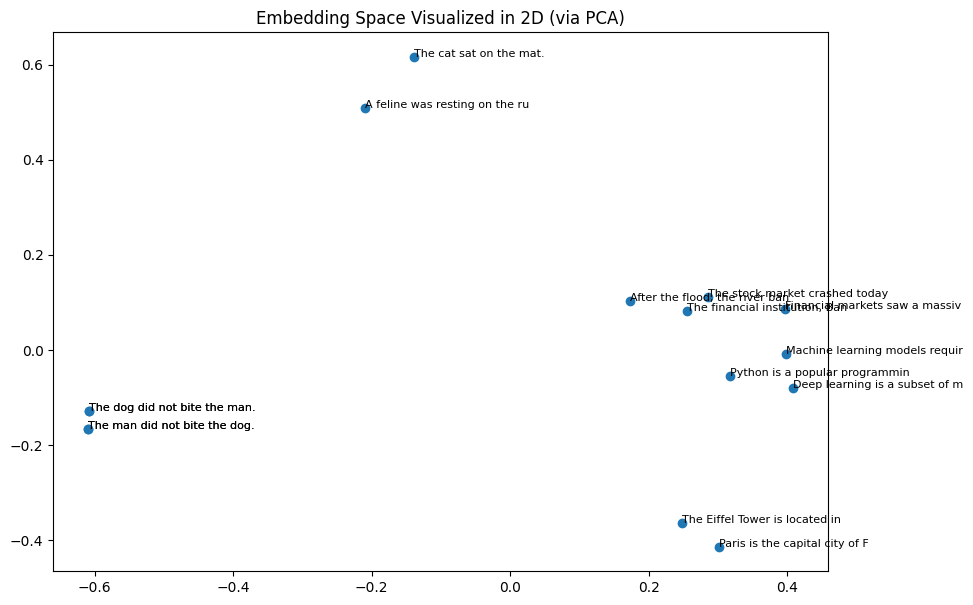

In [40]:
# ============================================
# CELL 5: Visualize embeddings in 2D (great intuition builder)
# ============================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

all_texts = sentences + documents
all_embeddings = model.encode(all_texts)

pca = PCA(n_components=2)
reduced = pca.fit_transform(all_embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(reduced[:, 0], reduced[:, 1])
for i, txt in enumerate(all_texts):
    plt.annotate(txt[:30], (reduced[i, 0], reduced[i, 1]), fontsize=8)
plt.title("Embedding Space Visualized in 2D (via PCA)")
plt.show()
# Notice: semantically related sentences cluster together visually

In [37]:
# ============================================
# CELL 6: Symmetric vs Asymmetric prefix experiment (real interview-relevant bug)
# ============================================
model_e5 = SentenceTransformer("BAAI/bge-small-en-v1.5")

query = "The dog did not bite the man."
doc = "The man did not bite the dog."

# WRONG way (no prefix) - e5 models expect prefixes
wrong_q = model_e5.encode([query])
wrong_d = model_e5.encode([doc])
print("Without prefix:", cosine_similarity(wrong_q, wrong_d)[0][0])

# CORRECT way (e5 requires "query: " and "passage: " prefixes)
right_q = model_e5.encode([f"query: {query}"])
right_d = model_e5.encode([f"passage: {doc}"])
print("With correct prefix:", cosine_similarity(right_q, right_d)[0][0])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Without prefix: 0.98574823
With correct prefix: 0.94473445
